<a href="https://colab.research.google.com/github/Yaire95/COVID-system/blob/master/Copy_of_assignment_2_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing
![](https://i.imgur.com/qkg2E2D.png)

## Assignment 002 - NER Tagger

> Notebook by:
> - NLP Course Staff
## Revision History

| Version | Date       | User        | Content / Changes                                                   |
|---------|------------|-------------|---------------------------------------------------------------------|
| 0.1.000 | 2026        | course staff | Updated submission protocol (direct from Colab) |

## Overview
In this assignment, you will build a complete training and testing pipeline for a neural sequential tagger for named entities using LSTM.

## Dataset
You will work with the ReCoNLL 2003 dataset, a corrected version of the [CoNLL 2003 dataset](https://www.clips.uantwerpen.be/conll2003/ner/):

**Click on the links below to download the data files.**
- [Train data](https://drive.google.com/file/d/1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf/view?usp=sharing)

- [Dev data](https://drive.google.com/file/d/1rdUida-j3OXcwftITBlgOh8nURhAYUDw/view?usp=sharing)

- [Test data](https://drive.google.com/file/d/137Ht40OfflcsE6BIYshHbT5b2iIJVaDx/view?usp=sharing)

As you will see, the annotated texts are labeled according to the `IOB` annotation scheme (more on this below), for 3 entity types: Person, Organization, Location.

## Your Implementation

This notebook **is** the assignment template. To work on it, open it in Colab using the badge below and then **File → Save a copy in Drive** to create your own editable copy.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1KGkObwUn5QQm_v0nB0nAUlB4YrwThuzl#scrollTo=Z-fCqGh9ybgm)

Work through the cells in order — each section's instructions are written above the corresponding code cell.

Good Luck 🤗


<!-- ## NER schemes:  

> `IO`: is the simplest scheme that can be applied to this task. In this scheme, each token from the dataset is assigned one of two tags: an inside tag (`I`) and an outside tag (`O`). The `I` tag is for named entities, whereas the `O` tag is for normal words. This scheme has a limitation, as it cannot correctly encode consecutive entities of the same type.

> `IOB`: This scheme is also referred to in the literature as BIO and has been adopted by the Conference on Computational Natural Language Learning (CoNLL) [1]. It assigns a tag to each word in the text, determining whether it is the beginning (`B`) of a known named entity, inside (`I`) it, or outside (`O`) of any known named entities.

> `IOE`: This scheme works nearly identically to `IOB`, but it indicates the end of the entity (`E` tag) instead of its beginning.

> `IOBES`: An alternative to the IOB scheme is `IOBES`, which increases the amount of information related to the boundaries of named entities. In addition to tagging words at the beginning (`B`), inside (`I`), end (`E`), and outside (`O`) of a named entity. It also labels single-token entities with the tag `S`.

> `BI`: This scheme tags entities in a similar method to `IOB`. Additionally, it labels the beginning of non-entity words with the tag B-O and the rest as I-O.

> `IE`: This scheme works exactly like `IOE` with the distinction that it labels the end of non-entity words with the tag `E-O` and the rest as `I-O`.

> `BIES`: This scheme encodes the entities similar to `IOBES`. In addition, it also encodes the non-entity words using the same method. It uses `B-O` to tag the beginning of non-entity words, `I-O` to tag the inside of non-entity words, and `S-O` for single non-entity tokens that exist between two entities. -->


## NER Schemes

### IO
- **Description**: The simplest scheme for named entity recognition (NER).
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Limitation**: Cannot correctly encode consecutive entities of the same type.

### IOB (BIO)
- **Description**: Adopted by the Conference on Computational Natural Language Learning (CoNLL).
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Advantage**: Can encode the boundaries of consecutive entities.

### IOE
- **Description**: Similar to IOB, but indicates the end of an entity.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
- **Advantage**: Focuses on the end boundary of entities.

### IOBES
- **Description**: An extension of IOB with additional boundary information.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
- **Advantage**: Provides more detailed boundary information for named entities.

### BI
- **Description**: Tags entities similarly to IOB and labels the beginning of non-entity words.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Distinguishes the beginning of non-entity sequences.

### IE
- **Description**: Similar to IOE but for non-entity words.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `E-O`: End of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Highlights the end of non-entity sequences.

### BIES
- **Description**: Encodes both entities and non-entity words using the IOBES method.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
  - `S-O`: Single non-entity token.
- **Advantage**: Comprehensive encoding for both entities and non-entities.




# Set up

In [46]:
!git clone https://github.com/NLP-Reichman/nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER.git
# Move into the cloned repo so the `data/...` paths below resolve.
%cd nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER


In [47]:
# Any additional needed libraries
# !pip install --q

In [48]:
# Standard Library Imports
import os
import copy
import random
import warnings
from collections import defaultdict
from typing import Optional

# ML
import numpy as np
import scipy as sp
import pandas as pd

# Visual
import matplotlib
import seaborn as sns
from tqdm import tqdm
from tabulate import tabulate
import matplotlib.pyplot as plt
from IPython.display import display

# DL
import torch as th
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset

# Metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score , roc_auc_score, classification_report, confusion_matrix, precision_recall_fscore_support

try:
    from google.colab import files
    COLAB = True
except ImportError:
    COLAB = False

In [49]:
SEED = 42
# Set the random seed for Python
random.seed(SEED)

# Set the random seed for numpy
np.random.seed(SEED)

# Set the random seed for pytorch
th.manual_seed(SEED)

# If using CUDA (for GPU operations)
th.cuda.manual_seed(SEED)

# Set up the device — this assignment expects a GPU runtime.
# In Colab: Runtime → Change runtime type → T4 GPU (or any available GPU).
# TO DO ----------------------------------------------------------------------
DEVICE = 'cuda'
# TO DO ----------------------------------------------------------------------
assert th.cuda.is_available(), "No GPU detected. In Colab: Runtime → Change runtime type → GPU."
assert DEVICE == "cuda", "DEVICE must be set to 'cuda'."

DataType = list[tuple[list[str],list[str]]]

# Part 1 - Dataset Preparation

## Step 1: Read Data
Write a function for reading the data from a single file (of the ones that are provided above).   
- The function recieves a filepath
- The funtion encodes every sentence individually using a pair of lists, one list contains the words and one list contains the tags.
- Each list pair will be added to a general list (data), which will be returned back from the function.

Example output:
```
[
  (['At','Trent','Bridge',':'],['O','B-LOC','I-LOC','O']),
  ([...],[...]),
  ...
]
```

In [50]:
def read_data(filepath: str) -> DataType:
  """
  Read CoNLL-style NER data from a single file.

  Each line stores a ``word<space>tag`` pair and sentences are separated by
  blank lines.
  :param filepath: path to the file
  :return: list of (words, tags) tuples, one per sentence
  """
  data: DataType = []
  words: list[str] = []
  tags: list[str] = []

  with open(filepath, encoding="utf-8") as f:
    for line in f:
      line = line.strip()
      # A blank line closes the current sentence.
      if not line:
        if words:
          data.append((words, tags))
          words, tags = [], []
        continue
      # Token line: first column is the word, last column is the IOB tag.
      columns = line.split()
      words.append(columns[0])
      tags.append(columns[-1])

  # Flush the last sentence if the file does not end with a blank line.
  if words:
    data.append((words, tags))

  return data

In [51]:
train = read_data("data/train.txt")
dev = read_data("data/dev.txt")
test = read_data("data/test.txt")

## Step 2: Create Vocab

The `Vocab` class will serve as a dictionary that maps words and tags into IDs. Ensure that you include special tokens to handle out-of-vocabulary words and padding.

### Your Task
1. **Define Special Tokens**: Define special tokens such as `PAD_TOKEN` and `UNK_TOKEN` and assign them unique IDs.
2. **Initialize Dictionaries**: Populate the word and tag dictionaries based on the training set.

*Note: You may change the `Vocab` class as needed.*

In [52]:
# Special-token ids. PAD is 0 so it also serves as the embedding padding_idx,
# and UNK is 1 so that every out-of-vocabulary word is mapped to id 1
# (see index_words below).
PAD_TOKEN = 0
UNK_TOKEN = 1

# Label id used to pad tag sequences. It matches the default ``ignore_index`` of
# nn.CrossEntropyLoss, so padded positions never contribute to the loss and never
# collide with a real tag id (this keeps the tag vocabulary at exactly 7 tags).
IGNORE_INDEX = -100


class Vocab:
  def __init__(self, train: DataType):
    """
    Build the word and tag vocabularies from the training set.
    :param train: train data
    """
    self.word2id = {"__unk__": UNK_TOKEN, "__pad__": PAD_TOKEN}
    self.id2word = {UNK_TOKEN: "__unk__", PAD_TOKEN: "__pad__"}
    self.n_words = 2

    self.tag2id = {}
    self.id2tag = {}
    self.n_tags = 0

    # Populate the dictionaries based on the training set only.
    for words, tags in train:
      for word in words:
        if word not in self.word2id:
          self.word2id[word] = self.n_words
          self.id2word[self.n_words] = word
          self.n_words += 1
      for tag in tags:
        if tag not in self.tag2id:
          self.tag2id[tag] = self.n_tags
          self.id2tag[self.n_tags] = tag
          self.n_tags += 1

  def __len__(self):
    return self.n_words

  def index_tags(self, tags: list[str]) -> list[int]:
    """
    Convert tags to Ids.
    :param tags: list of tags
    :return: list of Ids
    """
    tag_indexes = [self.tag2id[t] for t in tags]
    return tag_indexes

  def index_words(self, words: list[str]) -> list[int]:
    """
    Convert words to Ids.
    :param words: list of words
    :return: list of Ids
    """
    word_indexes = [self.word2id[w] if w in self.word2id else self.word2id["__unk__"] for w in words]
    return word_indexes

In [53]:
vocab = Vocab(train)

## Step 3: Prepare Data
Write a function `prepare_data` that takes one of the [train, dev, test] and the `Vocab` instance, for converting each pair of (words, tags) to a pair of indexes. Additionally, the function should pad the sequences to the maximum length sequence **of the given split**.

Note: Vocabulary is based only on the train set.

### Your Task
1. Convert each pair of (words, tags) to a pair of indexes using the Vocab instance.
2. Pad the sequences to the maximum length of the sequences in the given split.

In [54]:
def prepare_data(data: DataType, vocab: Vocab):
  """
  Convert a split into padded (word_ids, tag_ids) integer sequences.

  Every sentence is padded to the length of the longest sentence in *this* split:
  words are padded with PAD_TOKEN and tags with IGNORE_INDEX.
  :param data: a split (train / dev / test)
  :param vocab: the Vocab built on the train split
  :return: list of (word_ids, tag_ids) tuples
  """
  data_sequences = []
  if not data:
    return data_sequences

  max_len = max(len(words) for words, _ in data)
  for words, tags in data:
    word_ids = vocab.index_words(words)
    tag_ids = vocab.index_tags(tags)
    pad_len = max_len - len(word_ids)
    word_ids = word_ids + [PAD_TOKEN] * pad_len
    tag_ids = tag_ids + [IGNORE_INDEX] * pad_len
    data_sequences.append((word_ids, tag_ids))
  return data_sequences

In [55]:
train_sequences = prepare_data(train, vocab)
dev_sequences = prepare_data(dev, vocab)
test_sequences = prepare_data(test, vocab)

### Your Task
Print the number of OOV in dev and test sets:

In [56]:
def count_oov(sequences) -> int:
  """
  Count the number of OOV word tokens (words mapped to UNK_TOKEN).
  Padding positions hold PAD_TOKEN, so they are never counted.
  :param sequences: list of (word_ids, tag_ids) sequences
  :return: number of OOV words
  """
  oov = 0
  for word_ids, _ in sequences:
    oov += sum(1 for w in word_ids if w == UNK_TOKEN)
  return oov


# Print the number of OOV words in the dev and test splits.
print("Dev OOV: ", count_oov(dev_sequences))
print("Test OOV:", count_oov(test_sequences))

Dev OOV:  638
Test OOV: 1368


## Step 4: Dataloaders
Create dataloaders for each split in the dataset. They should return the samples as Tensors.

**Hint** - you can create a Dataset to support this part.

For the training set, use shuffling, and for the dev and test, not.

In [57]:
class NERDataset(Dataset):
  """Expose a list of padded (word_ids, tag_ids) sequences as tensors."""

  def __init__(self, sequences):
    self.sequences = sequences

  def __len__(self):
    return len(self.sequences)

  def __getitem__(self, idx):
    word_ids, tag_ids = self.sequences[idx]
    return th.tensor(word_ids, dtype=th.long), th.tensor(tag_ids, dtype=th.long)


def prepare_data_loader(sequences, batch_size: int, train: bool = True):
  """
  Create a dataloader from a list of sequences.
  :param sequences: list of (word_ids, tag_ids) sequences
  :param batch_size: batch size
  :param train: whether to shuffle the dataloader or not
  :return: dataloader yielding (inputs, labels) tensor batches
  """
  dataset = NERDataset(sequences)
  dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=train)
  return dataloader

In [58]:
BATCH_SIZE = 16
dl_train = prepare_data_loader(train_sequences, batch_size=BATCH_SIZE)
dl_dev = prepare_data_loader(dev_sequences, batch_size=BATCH_SIZE, train=False)
dl_test = prepare_data_loader(test_sequences, batch_size=BATCH_SIZE, train=False)

<br><br><br><br><br><br>

# Part 2 - NER Model Training

## Step 1: Implement Model

Write NERNet, a PyTorch Module for labeling words with NER tags.

> `input_size`: the size of the vocabulary  
`embedding_size`: the size of the embeddings  
`hidden_size`: the LSTM hidden size  
`output_size`: the number of tags we are predicting  
`n_layers`: the number of layers we want to use in LSTM  
`directions`: could 1 or 2, indicating unidirectional or bidirectional LSTM, respectively  

<br>  

The input for your forward function is a batch of sentence tensors with shape `(batch_size, seq_len)`.

*Note: the embeddings in this section are learned from scratch. That means you do **not** need pretrained embeddings here — you will use those in **Part 4**.*

*Note: You may change the NERNet class.*

In [59]:
class NERNet(nn.Module):
  def __init__(self, input_size: int, embedding_size: int, hidden_size: int, output_size: int, n_layers: int, directions: int):
    """
    Initialize a NERNet instance.
    :param input_size: the size of the vocabulary
    :param embedding_size: the size of the embeddings
    :param hidden_size: the LSTM hidden size
    :param output_size: the number of tags we are predicting
    :param n_layers: the number of layers we want to use in LSTM
    :param directions: 1 or 2, indicating a unidirectional or bidirectional LSTM
    """
    super(NERNet, self).__init__()
    self.embedding = nn.Embedding(input_size, embedding_size, padding_idx=PAD_TOKEN)
    self.lstm = nn.LSTM(
        input_size=embedding_size,
        hidden_size=hidden_size,
        num_layers=n_layers,
        batch_first=True,
        bidirectional=(directions == 2),
        dropout=0.3 if n_layers > 1 else 0.0,
    )
    self.fc = nn.Linear(hidden_size * directions, output_size)

  def forward(self, input_sentence):
    embedded = self.embedding(input_sentence)
    lstm_out, _ = self.lstm(embedded)
    output = self.fc(lstm_out)
    return output

In [60]:
model = NERNet(vocab.n_words, embedding_size=300, hidden_size=800, output_size=vocab.n_tags, n_layers=2, directions=1)
model.to(DEVICE)

NERNet(
  (embedding): Embedding(7163, 300, padding_idx=0)
  (lstm): LSTM(300, 800, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=800, out_features=7, bias=True)
)

## Step 2: Training Loop

Write a training loop, which takes a model (instance of NERNet), number of epochs to train on, and the train&dev datasets.  

The function will return the `loss` and `accuracy` durring training.  
(If you're using a different/additional metrics, return them too)

The loss is always CrossEntropyLoss and the optimizer is always Adam.
Make sure to use `tqdm` while iterating on `n_epochs`.


In [61]:
def train_loop(model: NERNet, n_epochs: int, dataloader_train, dataloader_dev):
  """
  Train a model with Adam and CrossEntropyLoss.
  :param model: model instance
  :param n_epochs: number of epochs to train on
  :param dataloader_train: train dataloader
  :param dataloader_dev: dev dataloader
  :return: per-epoch loss and accuracy for the train and dev splits
  """
  # Optimizer (ADAM is a fancy version of SGD)
  optimizer = Adam(model.parameters(), lr=0.0001)
  criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

  # Record
  metrics = {'loss': {'train': [], 'dev': []}, 'accuracy': {'train': [], 'dev': []}}

  # Move model to device
  model.to(DEVICE)

  def run_epoch(dataloader, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, total_correct, total_tokens = 0.0, 0, 0
    context = th.enable_grad() if train_mode else th.no_grad()
    with context:
      for inputs, labels in dataloader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        logits = outputs.view(-1, outputs.size(-1))
        targets = labels.view(-1)
        loss = criterion(logits, targets)

        if train_mode:
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

        mask = targets != IGNORE_INDEX
        n_tokens = int(mask.sum().item())
        preds = logits.argmax(dim=1)
        total_correct += int((preds[mask] == targets[mask]).sum().item())
        total_tokens += n_tokens
        total_loss += loss.item() * n_tokens

    avg_loss = total_loss / max(total_tokens, 1)
    accuracy = total_correct / max(total_tokens, 1)
    return avg_loss, accuracy

  for _ in tqdm(range(n_epochs), desc="Epochs"):
    train_loss, train_acc = run_epoch(dataloader_train, train_mode=True)
    dev_loss, dev_acc = run_epoch(dataloader_dev, train_mode=False)
    metrics['loss']['train'].append(train_loss)
    metrics['loss']['dev'].append(dev_loss)
    metrics['accuracy']['train'].append(train_acc)
    metrics['accuracy']['dev'].append(dev_acc)

  return metrics

In [62]:
metrics = train_loop(model, n_epochs=5, dataloader_train=dl_train, dataloader_dev=dl_dev)
metrics

Epochs: 100%|██████████| 5/5 [00:18<00:00,  3.70s/it]


{'loss': {'train': [1.0461884086309774,
   0.7477616892606229,
   0.6182845714862253,
   0.528076320022093,
   0.4552800552104764],
  'dev': [0.847032191833203,
   0.7008915569859049,
   0.605761202079162,
   0.5563207440363583,
   0.5259392793986388]},
 'accuracy': {'train': [0.7867440225035162,
   0.7915611814345992,
   0.8129043600562588,
   0.8274964838255977,
   0.8489803094233473],
  'dev': [0.7846817144306366,
   0.7993913264012174,
   0.8166370783667258,
   0.8280497083439006,
   0.8437737763124524]}}

<br><br><br><br><br><br>

# Part 3 - Evaluation


## Step 1: Evaluation Function

Write an evaluation loop for a trained model using the dev and test datasets. This function will print the `Recall`, `Precision`, and `F1` scores and plot a `Confusion Matrix`.

Perform this evaluation twice:
1. For all labels (7 labels in total).
2. For all labels except "O" (6 labels in total).

## Metrics and Display

### Metrics
- **Recall**: The fraction of true positives that were correctly predicted — TP / (TP + FN). Also known as the True Positive Rate (TPR).
- **Precision**: The fraction of predicted positives that are actually correct — TP / (TP + FP).
- **F1 Score**: The harmonic mean of Precision and Recall.

*Note*: For all these metrics, use **weighted** averaging:
Calculate metrics for each label, and find their average weighted by support. Refer to the [sklearn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html#sklearn.metrics.precision_recall_fscore_support) for more details.

### Display
1. Print the `Recall`, `Precision`, and `F1` scores in a tabulated format.
2. Display a `Confusion Matrix` plot:
   - Rows represent the predicted labels.
   - Columns represent the true labels.
   - Include a title for the plot, axis names, and the names of the tags on the X-axis.

In [63]:
def evaluate(model: NERNet, title: str, dataloader: DataLoader, vocab: Vocab, plot: bool = True):
  """
  Evaluate a trained model on the given dataset.
  :param model: model instance
  :param title: title for the plot
  :param dataloader: dataloader
  :param vocab: Vocab instance
  :return: Dictionary of evaluation results
  """
  model.eval()
  model.to(DEVICE)

  all_true, all_pred = [], []
  with th.no_grad():
    for inputs, labels in dataloader:
      inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
      outputs = model(inputs)
      preds = outputs.argmax(dim=2)
      mask = inputs != PAD_TOKEN
      all_true.extend(labels[mask].cpu().tolist())
      all_pred.extend(preds[mask].cpu().tolist())

  labels_all = list(range(vocab.n_tags))
  tag_names = [vocab.id2tag[i] for i in labels_all]

  precision, recall, f1, _ = precision_recall_fscore_support(
      all_true, all_pred, labels=labels_all, average='weighted', zero_division=0)

  o_id = vocab.tag2id.get('O')
  labels_wo_o = [i for i in labels_all if i != o_id]
  p_wo, r_wo, f_wo, _ = precision_recall_fscore_support(
      all_true, all_pred, labels=labels_wo_o, average='weighted', zero_division=0)

  results = {
      'Recall': recall, 'Precision': precision, 'F1': f1,
      'Recall_WO_O': r_wo, 'Precision_WO_O': p_wo, 'F1_WO_O': f_wo,
  }

  table = [
      ['All labels', recall, precision, f1],
      ['Without O', r_wo, p_wo, f_wo],
  ]
  print(tabulate(table, headers=['Scope', 'Recall', 'Precision', 'F1'],
                 tablefmt='psql', floatfmt='.4f'))

  if plot:
    cm = confusion_matrix(all_true, all_pred, labels=labels_all).T
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=tag_names, yticklabels=tag_names)
    plt.title(f'Confusion Matrix {title}'.strip())
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.tight_layout()
    plt.show()

  return results

## Step 2: Train & Evaluate on Dev Set

Train and evaluate (on the dev set) a few models, all with `embedding_size=300` and `N_EPOCHS=5` (for fairness and computational reasons), and with the following hyper parameters (you may use that as captions for the models as well):

- Model 1: (hidden_size: 500, n_layers: 1, directions: 1)
- Model 2: (hidden_size: 500, n_layers: 2, directions: 1)
- Model 3: (hidden_size: 500, n_layers: 3, directions: 1)
- Model 4: (hidden_size: 500, n_layers: 1, directions: 2)
- Model 5: (hidden_size: 500, n_layers: 2, directions: 2)
- Model 6: (hidden_size: 500, n_layers: 3, directions: 2)
- Model 7: (hidden_size: 800, n_layers: 1, directions: 2)
- Model 8: (hidden_size: 800, n_layers: 2, directions: 2)
- Model 9: (hidden_size: 800, n_layers: 3, directions: 2)




In [64]:
N_EPOCHS = 5
EMB_DIM = 300

Here is an example (random numbers) of the display of the results):

In [65]:
# Example:
results_acc = np.random.rand(9, 10)
columns = ['N_MODEL','HIDDEN_SIZE','N_LAYERS','DIRECTIONS','RECALL','PRECISION','F1','RECALL_WO_O','PRECISION_WO_O','F1_WO_O']
df = pd.DataFrame(results_acc, columns=columns)
df.N_MODEL = [f'model_{n}' for n in range(1,10)]
print(tabulate(df, headers='keys', tablefmt='psql',floatfmt=".4f"))

+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | model_1   |        0.9507 |     0.7320 |       0.5987 |   0.1560 |      0.1560 | 0.0581 |        0.8662 |           0.6011 |    0.7081 |
|  1 | model_2   |        0.9699 |     0.8324 |       0.2123 |   0.1818 |      0.1834 | 0.3042 |        0.5248 |           0.4319 |    0.2912 |
|  2 | model_3   |        0.1395 |     0.2921 |       0.3664 |   0.4561 |      0.7852 | 0.1997 |        0.5142 |           0.5924 |    0.0465 |
|  3 | model_4   |        0.1705 |     0.0651 |       0.9489 |   0.9656 |      0.8084 | 0.3046 |        0.0977 |           0.6842 |    0

In [66]:
# Define models with their hyperparameters
models = {
  'Model1': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 1, 'directions': 1},
  'Model2': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 2, 'directions': 1},
  'Model3': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 3, 'directions': 1},
  'Model4': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 1, 'directions': 2},
  'Model5': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 2, 'directions': 2},
  'Model6': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 3, 'directions': 2},
  'Model7': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 1, 'directions': 2},
  'Model8': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 2, 'directions': 2},
  'Model9': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 3, 'directions': 2},
}

results_dev = pd.DataFrame(columns=columns)
trained_models = {}

for idx, (name, cfg) in enumerate(models.items(), start=1):
  print(f"\n=== Training {name}: {cfg} ===")
  model_i = NERNet(vocab.n_words, embedding_size=cfg['embedding_size'],
                   hidden_size=cfg['hidden_size'], output_size=vocab.n_tags,
                   n_layers=cfg['n_layers'], directions=cfg['directions'])
  model_i.to(DEVICE)
  train_loop(model_i, n_epochs=N_EPOCHS, dataloader_train=dl_train, dataloader_dev=dl_dev)
  res = evaluate(model_i, title=name, dataloader=dl_dev, vocab=vocab, plot=False)

  trained_models[name] = model_i
  results_dev.loc[len(results_dev)] = [
      f'model_{idx}', cfg['hidden_size'], cfg['n_layers'], cfg['directions'],
      res['Recall'], res['Precision'], res['F1'],
      res['Recall_WO_O'], res['Precision_WO_O'], res['F1_WO_O'],
  ]

print(tabulate(results_dev, headers='keys', tablefmt='psql', floatfmt=".4f"))


=== Training Model1: {'embedding_size': 300, 'hidden_size': 500, 'n_layers': 1, 'directions': 1} ===


Epochs: 100%|██████████| 5/5 [00:04<00:00,  1.08it/s]


+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8192 |      0.7728 | 0.7692 |
| Without O  |   0.2007 |      0.5613 | 0.2813 |
+------------+----------+-------------+--------+

=== Training Model2: {'embedding_size': 300, 'hidden_size': 500, 'n_layers': 2, 'directions': 1} ===


Epochs: 100%|██████████| 5/5 [00:08<00:00,  1.68s/it]


+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8040 |      0.7762 | 0.7715 |
| Without O  |   0.2834 |      0.4626 | 0.2938 |
+------------+----------+-------------+--------+

=== Training Model3: {'embedding_size': 300, 'hidden_size': 500, 'n_layers': 3, 'directions': 1} ===


...

+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8595 |      0.8463 | 0.8367 |
| Without O  |   0.4274 |      0.6999 | 0.4963 |
+------------+----------+-------------+--------+

=== Training Model8: {'embedding_size': 300, 'hidden_size': 800, 'n_layers': 2, 'directions': 2} ===


Epochs: 100%|██████████| 5/5 [00:45<00:00,  9.17s/it]


+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8818 |      0.8760 | 0.8756 |
| Without O  |   0.6009 |      0.7025 | 0.6377 |
+------------+----------+-------------+--------+

=== Training Model9: {'embedding_size': 300, 'hidden_size': 800, 'n_layers': 3, 'directions': 2} ===


Epochs: 100%|██████████| 5/5 [01:14<00:00, 14.88s/it]


+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8958 |      0.8911 | 0.8840 |
| Without O  |   0.5490 |      0.8372 | 0.6562 |
+------------+----------+-------------+--------+
+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | model_1   |           500 |          1 |            1 |   0.8192 |      0.7728 | 0.7692 |        0.2007 |           0.5613 |    0.2813 |
|  1 | model_2   |           500 |          2 |            1 |   0.8040 |      0.7762 | 0.7715 |        0.2834 |           0.4626 

## Step 3: Evaluate on Test Set
Evaluate your models on the test set and save the results as a CSV.

+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8272 |      0.7909 | 0.7789 |
| Without O  |   0.1939 |      0.6000 | 0.2723 |
+------------+----------+-------------+--------+
+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8077 |      0.7631 | 0.7754 |
| Without O  |   0.2733 |      0.3747 | 0.2821 |
+------------+----------+-------------+--------+
+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8209 |      0.7554 | 0.7838 |
| Without O  |   0.2780 |      0.3379 | 0.2966 |
+------------+----------+-------------+--------+
+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+------

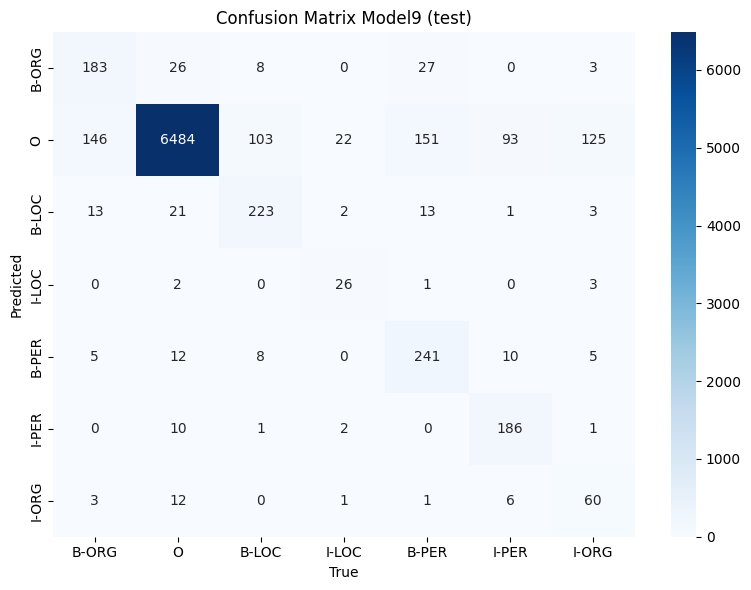

{'Recall': 0.8980953536333859,
 'Precision': 0.891499036327313,
 'F1': 0.8872639983559821,
 'Recall_WO_O': 0.5483293556085919,
 'Precision_WO_O': 0.8183694825084188,
 'F1_WO_O': 0.6524522643612768}

In [67]:
results = pd.DataFrame(columns=columns)
file_name = "NER_results.csv"

for idx, (name, cfg) in enumerate(models.items(), start=1):
  model_i = trained_models[name]
  res = evaluate(model_i, title=f'{name} (test)', dataloader=dl_test, vocab=vocab, plot=False)
  results.loc[len(results)] = [
      f'model_{idx}', cfg['hidden_size'], cfg['n_layers'], cfg['directions'],
      res['Recall'], res['Precision'], res['F1'],
      res['Recall_WO_O'], res['Precision_WO_O'], res['F1_WO_O'],
  ]

results.to_csv(file_name, index=False)
print(tabulate(results, headers='keys', tablefmt='psql', floatfmt=".4f"))

best_name = list(models.keys())[int(results['F1'].astype(float).idxmax())]
print(f"\nConfusion matrix for the best test model: {best_name}")
evaluate(trained_models[best_name], title=f'{best_name} (test)', dataloader=dl_test, vocab=vocab, plot=True)

## Step 4 - best model
Decide which model performs the best, write its configuration, train it for **10 epochs total** (5 more than the original 5), and evaluate it on the test set.

Best model configuration: {'embedding_size': 300, 'hidden_size': 800, 'n_layers': 3, 'directions': 2}


Epochs: 100%|██████████| 10/10 [02:28<00:00, 14.89s/it]


+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.9080 |      0.9071 | 0.9050 |
| Without O  |   0.6885 |      0.7276 | 0.6957 |
+------------+----------+-------------+--------+


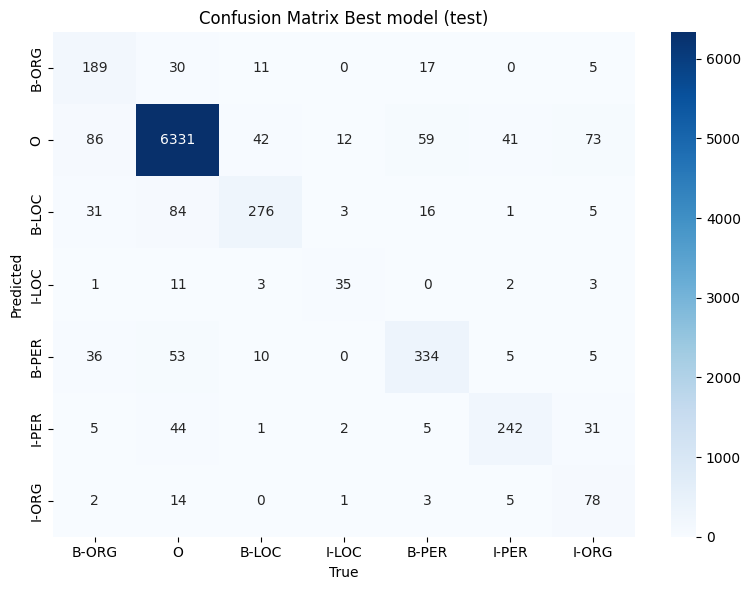

Test F1: 0.9050 | Test F1 (w/o O): 0.6957


In [68]:
best_model_cfg = {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 2, 'directions': 2}
try:
  best_row = results_dev.loc[results_dev['F1'].astype(float).idxmax()]
  best_model_cfg = {
      'embedding_size': EMB_DIM,
      'hidden_size': int(best_row['HIDDEN_SIZE']),
      'n_layers': int(best_row['N_LAYERS']),
      'directions': int(best_row['DIRECTIONS']),
  }
except (NameError, KeyError, ValueError):
  pass

print("Best model configuration:", best_model_cfg)

best_model = NERNet(vocab.n_words, embedding_size=best_model_cfg['embedding_size'],
                    hidden_size=best_model_cfg['hidden_size'], output_size=vocab.n_tags,
                    n_layers=best_model_cfg['n_layers'], directions=best_model_cfg['directions'])
best_model.to(DEVICE)
train_loop(best_model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
best_results = evaluate(best_model, title="Best model (test)", dataloader=dl_test, vocab=vocab)
print(f"Test F1: {best_results['F1']:.4f} | Test F1 (w/o O): {best_results['F1_WO_O']:.4f}")

<br><br><br><br><br>

# Part 4 - Pretrained Embeddings



To prepare for this task, please read [this discussion](https://discuss.pytorch.org/t/can-we-use-pre-trained-word-embeddings-for-weight-initialization-in-nn-embedding/1222).

**TIP**: Ensure that the vectors are aligned with the IDs in your vocabulary. In other words, make sure that the word with ID 0 corresponds to the first vector in the GloVe matrix used to initialize `nn.Embedding`.



## Step 1: Get Data



Download the GloVe embeddings from [this link](https://nlp.stanford.edu/projects/glove/). Use the 300-dimensional vectors from `glove.6B.zip`.



In [69]:
# Download the 300d GloVe vectors (glove.6B) and extract glove.6B.300d.txt.
import zipfile
import urllib.request

GLOVE_TXT = "glove.6B.300d.txt"
GLOVE_ZIP = "glove.6B.zip"

if not os.path.exists(GLOVE_TXT):
  if not os.path.exists(GLOVE_ZIP):
    url = "https://nlp.stanford.edu/data/glove.6B.zip"
    print(f"Downloading GloVe embeddings from {url} ...")
    urllib.request.urlretrieve(url, GLOVE_ZIP)
  print("Extracting glove.6B.300d.txt ...")
  with zipfile.ZipFile(GLOVE_ZIP) as zf:
    zf.extract(GLOVE_TXT)

print("GloVe ready:", os.path.exists(GLOVE_TXT))

GloVe ready: True


## Step 2: Inject Embeddings

Then intialize the `nn.Embedding` module in your `NERNet` with these embeddings, so that you can start your training with pre-trained vectors.

In [70]:
def get_emb_matrix(filepath: str, vocab: Vocab) -> np.ndarray:
  """
  Build an embedding matrix aligned with ``vocab.word2id``.

  Row i holds the GloVe vector for the word whose id is i. Words missing from
  GloVe get a small random vector; the PAD row is kept at zero.
  :param filepath: path to the GloVe txt file
  :param vocab: Vocab instance
  :return: (vocab_size, 300) embedding matrix
  """
  emb_dim = 300
  rng = np.random.default_rng(SEED)
  emb_matrix = rng.normal(scale=0.6, size=(len(vocab.word2id), emb_dim)).astype(np.float32)
  emb_matrix[PAD_TOKEN] = 0.0

  found = 0
  with open(filepath, encoding="utf-8") as f:
    for line in f:
      values = line.rstrip().split(' ')
      word = values[0]
      if word in vocab.word2id:
        emb_matrix[vocab.word2id[word]] = np.asarray(values[1:], dtype=np.float32)
        found += 1

  print(f"Found pretrained vectors for {found}/{len(vocab.word2id)} words.")
  return emb_matrix

In [71]:
def initialize_from_pretrained_emb(model: NERNet, emb_matrix: np.ndarray):
  """
  Inject the pretrained embeddings into the model's nn.Embedding layer.
  The padding row is reset to zero; embeddings stay trainable (fine-tuned).
  :param model: model instance
  :param emb_matrix: pretrained embeddings aligned with vocab ids
  """
  weights = th.from_numpy(emb_matrix).float()
  model.embedding.weight.data.copy_(weights)
  model.embedding.weight.data[PAD_TOKEN] = 0.0

In [72]:
# Read embeddings and inject them to a model
emb_file = 'glove.6B.300d.txt'
emb_matrix = get_emb_matrix(emb_file, vocab)
ner_glove = NERNet(input_size=vocab.n_words, embedding_size=EMB_DIM, hidden_size=500, output_size=vocab.n_tags, n_layers=1, directions=1)
initialize_from_pretrained_emb(ner_glove, emb_matrix)

Found pretrained vectors for 3737/7163 words.


## Step 3: Evaluate on Test Set

Same as the evaluation process before, please display:

1. Print a `RECALL-PRECISION-F1` scores in a tabulate format.
2. Display a `confusion matrix` plot: where the predicted labels are the rows, and the true labels are the columns.

Make sure to use the title for the plot, axis names, and the names of the tags on the X-axis.

The CSV will be submitted automatically along with your results.


=== Training Model1 (GloVe init): {'embedding_size': 300, 'hidden_size': 500, 'n_layers': 1, 'directions': 1} ===


Epochs: 100%|██████████| 5/5 [00:04<00:00,  1.06it/s]


+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8186 |      0.8321 | 0.8120 |
| Without O  |   0.4212 |      0.4485 | 0.3692 |
+------------+----------+-------------+--------+

=== Training Model2 (GloVe init): {'embedding_size': 300, 'hidden_size': 500, 'n_layers': 2, 'directions': 1} ===


Epochs: 100%|██████████| 5/5 [00:08<00:00,  1.76s/it]


+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.7905 |      0.7940 | 0.7837 |
| Without O  |   0.3699 |      0.2780 | 0.2828 |
+------------+----------+-------------+--------+

=== Training Model3 (GloVe init): {'embedding_size': 300, 'hidden_size': 500, 'n_layers': 3, 'directions': 1} ===


...

+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8539 |      0.8677 | 0.8559 |
| Without O  |   0.5758 |      0.5464 | 0.5378 |
+------------+----------+-------------+--------+

=== Training Model8 (GloVe init): {'embedding_size': 300, 'hidden_size': 800, 'n_layers': 2, 'directions': 2} ===


Epochs: 100%|██████████| 5/5 [00:46<00:00,  9.26s/it]


+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8329 |      0.8840 | 0.8434 |
| Without O  |   0.6444 |      0.5774 | 0.5439 |
+------------+----------+-------------+--------+

=== Training Model9 (GloVe init): {'embedding_size': 300, 'hidden_size': 800, 'n_layers': 3, 'directions': 2} ===


Epochs: 100%|██████████| 5/5 [01:13<00:00, 14.78s/it]


+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8048 |      0.8889 | 0.8282 |
| Without O  |   0.6569 |      0.5189 | 0.5176 |
+------------+----------+-------------+--------+
+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | model_1   |           500 |          1 |            1 |   0.8186 |      0.8321 | 0.8120 |        0.4212 |           0.4485 |    0.3692 |
|  1 | model_2   |           500 |          2 |            1 |   0.7905 |      0.7940 | 0.7837 |        0.3699 |           0.2780 

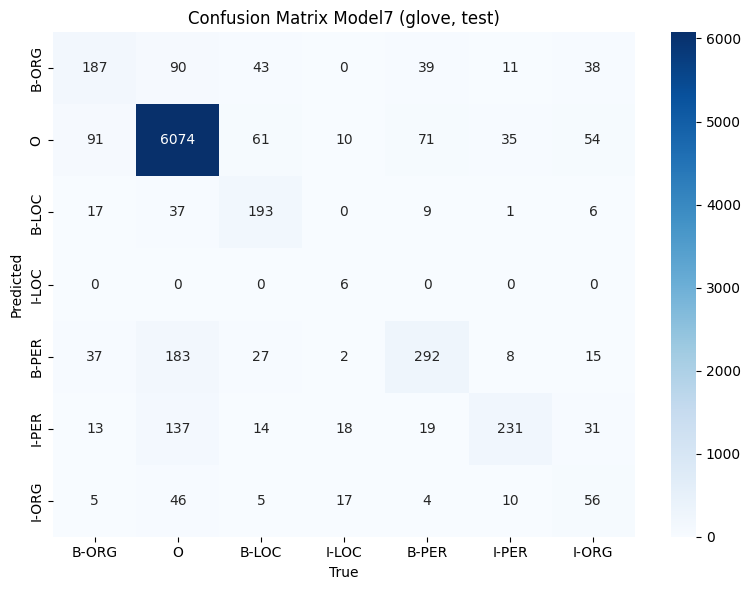

{'Recall': 0.8539366735411864,
 'Precision': 0.8676710096257474,
 'F1': 0.8559405523852461,
 'Recall_WO_O': 0.5757756563245824,
 'Precision_WO_O': 0.5464325479452821,
 'F1_WO_O': 0.5378242631837072}

In [73]:
# Train each configuration with GloVe-initialized embeddings and evaluate on test.
results = pd.DataFrame(columns=columns)
file_name = "NER_results_glove.csv"
trained_models_glove = {}

for idx, (name, cfg) in enumerate(models.items(), start=1):
  print(f"\n=== Training {name} (GloVe init): {cfg} ===")
  model_i = NERNet(vocab.n_words, embedding_size=cfg['embedding_size'],
                   hidden_size=cfg['hidden_size'], output_size=vocab.n_tags,
                   n_layers=cfg['n_layers'], directions=cfg['directions'])
  model_i.to(DEVICE)
  initialize_from_pretrained_emb(model_i, emb_matrix)
  train_loop(model_i, n_epochs=N_EPOCHS, dataloader_train=dl_train, dataloader_dev=dl_dev)
  res = evaluate(model_i, title=f'{name} (glove, test)', dataloader=dl_test, vocab=vocab, plot=False)

  trained_models_glove[name] = model_i
  results.loc[len(results)] = [
      f'model_{idx}', cfg['hidden_size'], cfg['n_layers'], cfg['directions'],
      res['Recall'], res['Precision'], res['F1'],
      res['Recall_WO_O'], res['Precision_WO_O'], res['F1_WO_O'],
  ]

results.to_csv(file_name, index=False)
print(tabulate(results, headers='keys', tablefmt='psql', floatfmt=".4f"))

# Display a confusion matrix for the best-performing GloVe model on the test set.
best_name = list(models.keys())[int(results['F1'].astype(float).idxmax())]
print(f"\nConfusion matrix for the best GloVe test model: {best_name}")
evaluate(trained_models_glove[best_name], title=f'{best_name} (glove, test)', dataloader=dl_test, vocab=vocab, plot=True)

## Step 4 - best model
Decide which model performs the best, write its configuration, train it for **10 epochs total** (5 more than the original 5), and evaluate it on the test set.

Best GloVe model configuration: {'embedding_size': 300, 'hidden_size': 800, 'n_layers': 1, 'directions': 2}


Epochs: 100%|██████████| 10/10 [00:35<00:00,  3.55s/it]


+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8468 |      0.8866 | 0.8588 |
| Without O  |   0.6981 |      0.5416 | 0.5897 |
+------------+----------+-------------+--------+


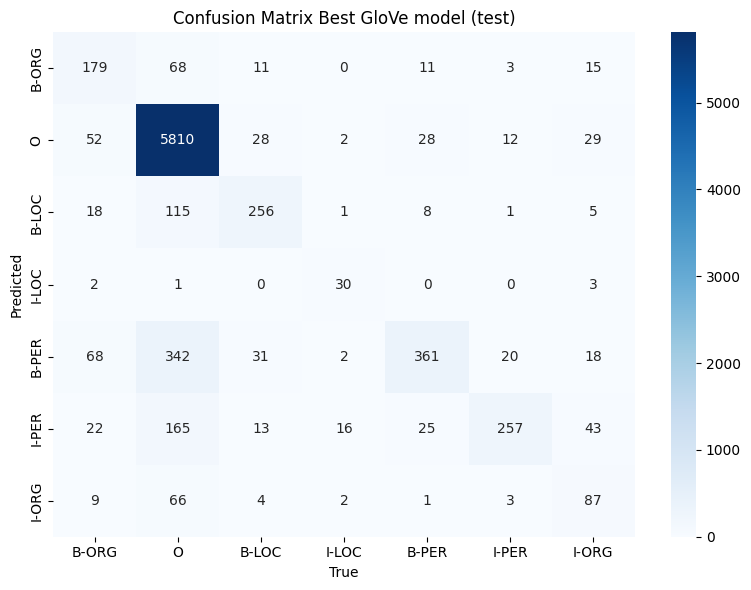

Test F1: 0.8588 | Test F1 (w/o O): 0.5897


In [74]:
best_model_glove_cfg = {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 2, 'directions': 2}
try:
  best_row = results.loc[results['F1'].astype(float).idxmax()]
  best_model_glove_cfg = {
      'embedding_size': EMB_DIM,
      'hidden_size': int(best_row['HIDDEN_SIZE']),
      'n_layers': int(best_row['N_LAYERS']),
      'directions': int(best_row['DIRECTIONS']),
  }
except (NameError, KeyError, ValueError):
  pass

print("Best GloVe model configuration:", best_model_glove_cfg)

best_model_glove = NERNet(vocab.n_words, embedding_size=best_model_glove_cfg['embedding_size'],
                          hidden_size=best_model_glove_cfg['hidden_size'], output_size=vocab.n_tags,
                          n_layers=best_model_glove_cfg['n_layers'], directions=best_model_glove_cfg['directions'])
best_model_glove.to(DEVICE)
initialize_from_pretrained_emb(best_model_glove, emb_matrix)
train_loop(best_model_glove, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
best_glove_results = evaluate(best_model_glove, title="Best GloVe model (test)", dataloader=dl_test, vocab=vocab)
print(f"Test F1: {best_glove_results['F1']:.4f} | Test F1 (w/o O): {best_glove_results['F1_WO_O']:.4f}")

# Part 5 - Error Analysis

In this part, you'll analyze the errors made by your best model to understand its strengths and weaknesses.

## Step 1: Extract Predictions

First, let's extract predictions from your best model on the test set:

In [75]:
def get_predictions(model, dataloader, vocab, PAD_TOKEN, DEVICE):
    """
    Get predictions from the model on a dataloader.

    Returns:
        - true_tags_list: List of lists of true tag strings
        - pred_tags_list: List of lists of predicted tag strings
        - words_list: List of lists of words
    """
    import torch

    model.eval()
    true_tags_list = []
    pred_tags_list = []
    words_list = []

    with torch.no_grad():
        for batch in dataloader:
            # Dataloader yields (input_ids, labels) pairs.
            input_ids, labels = batch
            input_ids = input_ids.to(DEVICE)
            labels = labels.to(DEVICE)

            # Get model predictions.
            outputs = model(input_ids)
            _, predicted = torch.max(outputs, 2)

            # Process each sequence in the batch.
            for i in range(input_ids.size(0)):
                # Get sequence length (ignoring padding).
                seq_len = (input_ids[i] != PAD_TOKEN).sum().item()

                # Convert ids back to tag strings and words.
                true_tags = [vocab.id2tag[tag.item()] for tag in labels[i][:seq_len]]
                pred_tags = [vocab.id2tag[tag.item()] for tag in predicted[i][:seq_len]]
                words = [vocab.id2word[word.item()] for word in input_ids[i][:seq_len]]

                true_tags_list.append(true_tags)
                pred_tags_list.append(pred_tags)
                words_list.append(words)

    return true_tags_list, pred_tags_list, words_list

## Step 2: Helper Functions

Before writing the error analysis, implement two utility functions that you will need.

### 2a: `get_entities_simple(tags)`

**Goal:** Extract named entities from a single IOB tag sequence.

**Input:** A list of IOB tag strings, e.g. `['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'O']`

**Output:** A list of tuples `(start_idx, end_idx, entity_type)` where:
- `start_idx` is the index of the `B-` tag
- `end_idx` is the index of the last `I-` tag of that entity (or same as `start_idx` if the entity is a single token)
- `entity_type` is the string after `B-`/`I-` (e.g. `"PER"`, `"LOC"`, `"ORG"`)

**Logic:** Walk through the tag list. When you see a `B-X` tag, start a new entity. Keep extending it while the next tags are `I-X` (same type). When the entity ends, append the tuple. Ignore `O` tags.

**Example:**
```python
tags = ['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'O']
get_entities_simple(tags)
# Returns: [(1, 2, 'PER'), (4, 4, 'LOC')]
```

### 2b: `has_overlap(start1, end1, start2, end2)`

**Goal:** Check if two index spans share at least one position.

**Input:** Four integers — start and end indices of two spans.

**Output:** `True` if they overlap, `False` otherwise.

**Example:**
```python
has_overlap(1, 3, 2, 5)  # True  (overlap at indices 2, 3)
has_overlap(1, 2, 4, 5)  # False (no shared indices)
```

In [76]:
def get_entities_simple(tags):
    """
    Extract entities from a sequence of IOB tags.

    Args:
        tags: List of tag strings, e.g. ['O', 'B-PER', 'I-PER', 'O']

    Returns:
        List of (start_idx, end_idx, entity_type) tuples.
        Example: [(1, 2, 'PER')]
    """
    entities = []
    start = None
    ent_type = None

    for i, tag in enumerate(tags):
        if tag.startswith('B-'):
            # Close any open entity, then open a new one.
            if start is not None:
                entities.append((start, i - 1, ent_type))
            start, ent_type = i, tag[2:]
        elif tag.startswith('I-'):
            t = tag[2:]
            # Continue the open entity only if the type matches.
            if start is not None and t == ent_type:
                continue
            # Otherwise treat this I- as the start of a new entity (robustness).
            if start is not None:
                entities.append((start, i - 1, ent_type))
            start, ent_type = i, t
        else:  # 'O' or any other tag closes the open entity.
            if start is not None:
                entities.append((start, i - 1, ent_type))
                start, ent_type = None, None

    if start is not None:
        entities.append((start, len(tags) - 1, ent_type))

    return entities

def has_overlap(start1, end1, start2, end2):
    """
    Check if two spans overlap (share at least one index).

    Args:
        start1, end1: start and end indices of the first span
        start2, end2: start and end indices of the second span

    Returns:
        True if the spans overlap, False otherwise.
    """
    return start1 <= end2 and start2 <= end1

## Step 3: Implement Entity-Level Error Analysis

**Goal:** Compare the true and predicted entity spans (extracted using `get_entities_simple`) to count and categorize errors at the **entity level**.

**Function signature:**
```python
def simple_analyze_errors(true_tags, pred_tags, words) -> dict
```

**Inputs:**
- `true_tags`: list of lists of tag strings (one inner list per sentence)
- `pred_tags`: list of lists of tag strings (one inner list per sentence)
- `words`: list of lists of word strings (one inner list per sentence)

**What to do — for each sentence:**
1. Extract true entities using `get_entities_simple(true_tags[i])`
2. Extract predicted entities using `get_entities_simple(pred_tags[i])`
3. Classify each **true entity** into one of these categories:
   - **Correct:** A predicted entity has the exact same `(start, end, type)`.
   - **Type error:** A predicted entity has the same `(start, end)` but a **different** type (e.g., true=`PER`, predicted=`ORG`).
   - **Boundary error:** A predicted entity **overlaps** (use `has_overlap`) and has the **same type**, but the start/end indices differ.
   - **Missed:** No predicted entity overlaps with this true entity at all.
4. Also count **Spurious** predictions: predicted entities that do **not** overlap with any true entity.

**Return value — a dictionary:**
```python
{
    'total_entities': int,       # total number of true entities across all sentences
    'correct_entities': int,     # number of exact matches
    'accuracy': float,           # correct_entities / total_entities
    'error_counts': {
        'type_error': int,
        'boundary_error': int,
        'missed': int,
        'spurious': int
    },
    'error_examples': {          # store up to 3 examples per category
        'type_error': [(words, true_entity, pred_entity), ...],
        'boundary_error': [(words, true_entity, pred_entity), ...],
        'missed': [(words, true_entity), ...],
        'spurious': [(words, pred_entity), ...]
    }
}
```

**Example walkthrough:**
```python
true_tags = [['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'I-LOC', 'O']]
pred_tags = [['O', 'B-PER', 'O',     'O', 'B-ORG', 'I-ORG', 'O']]
words     = [['The', 'John', 'Smith', 'visited', 'New', 'York', 'yesterday']]

# True entities:  [(1,2,'PER'), (4,5,'LOC')]
# Pred entities:  [(1,1,'PER'), (4,5,'ORG')]
#
# (1,2,'PER') vs (1,1,'PER') → boundary_error (same type PER, overlapping spans, but end differs)
# (4,5,'LOC') vs (4,5,'ORG') → type_error (same span, different type)
```

In [77]:
def simple_analyze_errors(true_tags, pred_tags, words):
    """
    Analyze errors in NER predictions at the entity level.

    Args:
        true_tags: List of lists of true tag strings (one list per sentence)
        pred_tags: List of lists of predicted tag strings (one list per sentence)
        words: List of lists of word strings (one list per sentence)

    Returns:
        dict with keys: total_entities, correct_entities, accuracy,
                        error_counts (dict), error_examples (dict),
                        error_by_type (dict, errors per true/pred entity type)
    """
    error_counts = {'type_error': 0, 'boundary_error': 0, 'missed': 0, 'spurious': 0}
    error_examples = {'type_error': [], 'boundary_error': [], 'missed': [], 'spurious': []}
    error_by_type = defaultdict(int)
    total_entities = 0
    correct_entities = 0

    for sent_true, sent_pred, sent_words in zip(true_tags, pred_tags, words):
        true_entities = get_entities_simple(sent_true)
        pred_entities = get_entities_simple(sent_pred)

        # Classify every TRUE entity.
        for (t_start, t_end, t_type) in true_entities:
            total_entities += 1
            category = 'missed'
            matched_pred = None

            # 1) Exact match: same span and same type.
            for (p_start, p_end, p_type) in pred_entities:
                if (p_start, p_end) == (t_start, t_end) and p_type == t_type:
                    category, matched_pred = 'correct', (p_start, p_end, p_type)
                    break

            # 2) Type error: same span, different type.
            if category == 'missed':
                for (p_start, p_end, p_type) in pred_entities:
                    if (p_start, p_end) == (t_start, t_end) and p_type != t_type:
                        category, matched_pred = 'type_error', (p_start, p_end, p_type)
                        break

            # 3) Boundary error: overlapping span, same type, different boundaries.
            if category == 'missed':
                for (p_start, p_end, p_type) in pred_entities:
                    if (p_type == t_type and has_overlap(t_start, t_end, p_start, p_end)
                            and (p_start, p_end) != (t_start, t_end)):
                        category, matched_pred = 'boundary_error', (p_start, p_end, p_type)
                        break

            if category == 'correct':
                correct_entities += 1
            else:
                error_counts[category] += 1
                error_by_type[t_type] += 1
                if category == 'missed':
                    if len(error_examples['missed']) < 3:
                        error_examples['missed'].append((sent_words, (t_start, t_end, t_type)))
                elif len(error_examples[category]) < 3:
                    error_examples[category].append(
                        (sent_words, (t_start, t_end, t_type), matched_pred))

        # Count SPURIOUS predictions: no overlap with any true entity.
        for (p_start, p_end, p_type) in pred_entities:
            overlaps_any = any(has_overlap(p_start, p_end, ts, te)
                               for (ts, te, _) in true_entities)
            if not overlaps_any:
                error_counts['spurious'] += 1
                error_by_type[p_type] += 1
                if len(error_examples['spurious']) < 3:
                    error_examples['spurious'].append((sent_words, (p_start, p_end, p_type)))

    accuracy = correct_entities / total_entities if total_entities else 0.0

    return {
        'total_entities': total_entities,
        'correct_entities': correct_entities,
        'accuracy': accuracy,
        'error_counts': error_counts,
        'error_examples': error_examples,
        'error_by_type': dict(error_by_type),
    }

## Step 4: Display the Error Analysis

**Goal:** Print a readable summary of the error analysis dictionary returned by `simple_analyze_errors`.

**Function signature:**
```python
def print_error_analysis(analysis):
```

**Input:** The dictionary returned by `simple_analyze_errors`.

**What to print — three sections:**

**Section 1 — Overall statistics** (use `tabulate` or simple print statements):
```
Total entities:     500
Correct:            420 (84.0%)
Type errors:         15
Boundary errors:     25
Missed:              40
Spurious:            30
```

**Section 2 — Examples for each error type.** Print up to 3 examples per category, showing the sentence words and the relevant entity span. Format each example like:
```
[Type Error] "... New York ..." — true: LOC(4,5), predicted: ORG(4,5)
[Missed]     "... John Smith ..." — true: PER(1,2), predicted: (none)
```

**Section 3 — Which entity type (PER / LOC / ORG) has the most errors?** Print one line stating the answer.

In [78]:
def print_error_analysis(analysis):
    """
    Print a readable summary of the error analysis results.

    Args:
        analysis: Dictionary returned by simple_analyze_errors.
    """
    ec = analysis['error_counts']
    total = analysis['total_entities']
    correct = analysis['correct_entities']
    pct = (correct / total * 100) if total else 0.0

    # Section 1: overall statistics.
    print("=" * 52)
    print("Entity-Level Error Analysis")
    print("=" * 52)
    print(f"Total entities:   {total:6d}")
    print(f"Correct:          {correct:6d} ({pct:.1f}%)")
    print(f"Type errors:      {ec['type_error']:6d}")
    print(f"Boundary errors:  {ec['boundary_error']:6d}")
    print(f"Missed:           {ec['missed']:6d}")
    print(f"Spurious:         {ec['spurious']:6d}")

    def snippet(words, span):
        s, e, _ = span
        lo, hi = max(0, s - 1), min(len(words), e + 2)
        return " ".join(words[lo:hi])

    # Section 2: up to 3 examples per error category.
    print("\n--- Examples ---")
    for (w, true_ent, pred_ent) in analysis['error_examples']['type_error']:
        ts, te, tt = true_ent
        ps, pe, pt = pred_ent
        print(f'[Type Error] "... {snippet(w, true_ent)} ..." '
              f'— true: {tt}({ts},{te}), predicted: {pt}({ps},{pe})')
    for (w, true_ent, pred_ent) in analysis['error_examples']['boundary_error']:
        ts, te, tt = true_ent
        ps, pe, pt = pred_ent
        print(f'[Boundary]   "... {snippet(w, true_ent)} ..." '
              f'— true: {tt}({ts},{te}), predicted: {pt}({ps},{pe})')
    for (w, true_ent) in analysis['error_examples']['missed']:
        ts, te, tt = true_ent
        print(f'[Missed]     "... {snippet(w, true_ent)} ..." '
              f'— true: {tt}({ts},{te}), predicted: (none)')
    for (w, pred_ent) in analysis['error_examples']['spurious']:
        ps, pe, pt = pred_ent
        print(f'[Spurious]   "... {snippet(w, pred_ent)} ..." '
              f'— true: (none), predicted: {pt}({ps},{pe})')

    # Section 3: which entity type has the most errors?
    error_by_type = analysis.get('error_by_type', {})
    print("\n--- Errors by entity type ---")
    if error_by_type:
        for ent_type, count in sorted(error_by_type.items(), key=lambda kv: -kv[1]):
            print(f"  {ent_type}: {count}")
        worst = max(error_by_type, key=error_by_type.get)
        print(f"\nEntity type with the most errors: {worst} "
              f"({error_by_type[worst]} errors)")
    else:
        print("  No errors recorded.")

## Step 5: Improvement Suggestions

**Goal:** Based on the output of your error analysis, write **3 concrete improvement suggestions** below (no code required — just text).

**Requirements:**
- Write 2–4 sentences per suggestion.
- Each suggestion **must reference a specific finding** from your error analysis (e.g., "42% of errors are boundary errors on PER entities, which suggests...").
- Choose 3 of the following directions:
  1. Using a **CRF layer** on top of the LSTM to enforce valid IOB transitions
  2. Using **subword or character-level embeddings** to handle rare / OOV entity words
  3. Adding more **training data or data augmentation** for the weakest entity type
  4. Using **contextual embeddings** (e.g., BERT) instead of static word embeddings
  5. **Post-processing rules** to fix common boundary errors

**Expected output:** A markdown cell (below) with three numbered paragraphs.

In [79]:
# First, extract predictions from your best model on the test set
true_tags_list, pred_tags_list, words_list = get_predictions(model, dl_test, vocab, PAD_TOKEN, DEVICE)

# Run the error analysis
analysis = simple_analyze_errors(true_tags_list, pred_tags_list, words_list)

# Display the results
print_error_analysis(analysis)

Entity-Level Error Analysis
Total entities:     1127
Correct:             332 (29.5%)
Type errors:          48
Boundary errors:      81
Missed:              666
Spurious:             92

--- Examples ---
[Type Error] "... 0 Steve Jones through ..." — true: PER(1,2), predicted: ORG(1,2)
[Type Error] "... COMMACK , ..." — true: LOC(0,0), predicted: PER(0,0)
[Type Error] "... Fox said ..." — true: PER(0,0), predicted: LOC(0,0)
[Boundary]   "... ( K. __unk__ 52 ..." — true: PER(3,4), predicted: PER(4,4)
[Boundary]   "... ( D. Cox 95 ..." — true: PER(6,7), predicted: PER(7,7)
[Boundary]   "... 1 __unk__ __unk__ 1 ..." — true: ORG(2,3), predicted: ORG(2,2)
[Missed]     "... __unk__ __unk__ is ..." — true: PER(0,1), predicted: (none)
[Missed]     "... MILWAUKEE 61 ..." — true: ORG(0,0), predicted: (none)
[Missed]     "... __unk__ , ..." — true: LOC(0,0), predicted: (none)
[Spurious]   "... - Golf : ..." — true: (none), predicted: PER(2,2)
[Spurious]   "... Traders in ..." — true: (none), pred

### Your Improvement Suggestions


1. **Use subword / character-level embeddings for rare and OOV words.** This targets the single biggest failure: 666 missed entities, whose examples are dominated by `__unk__` tokens and capitalised single tokens the model never sees in training. With ~1368 OOV tokens in the test split, every rare entity word goes to one shared `__unk__` vector and loses all lexical signal. A character-level CNN/BiLSTM (or subword units) lets the model overcome this.

2. **Use contextual embeddings (e.g. BERT).** Because BERT tokenises into subwords, it removes the `__unk__` bottleneck behind most of our 666 missed entities. It should also help the ORG class, which has the most errors, since organisation names are heavily context-dependent.

3. **Add training data / augmentation for the weakest entity type (ORG).** The errors-by-type chart shows ORG is hardest (335 errors vs 319 PER and 233 LOC), and many missed entities are organisation names. Augmenting the training data with more ORG examples — or synthetically substituting entity names into existing sentences would broaden coverage of organisation and cut the missed-ORG rate.

# Testing

Before running the tests:
1. Create a **sharing link** to your notebook with **editor access**.
2. Paste it in the `NOTEBOOK_LINK` variable below.

Then run the test cells to create the `results.json` file.

In [80]:
NOTEBOOK_LINK = 'https://colab.research.google.com/drive/1n4sbJRpELzO-WGxPL3IXyPqv7-bcHE3F?usp=sharing'

Epochs: 100%|██████████| 10/10 [02:28<00:00, 14.87s/it]


+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.9093 |      0.9098 | 0.9082 |
| Without O  |   0.6891 |      0.7407 | 0.7084 |
+------------+----------+-------------+--------+


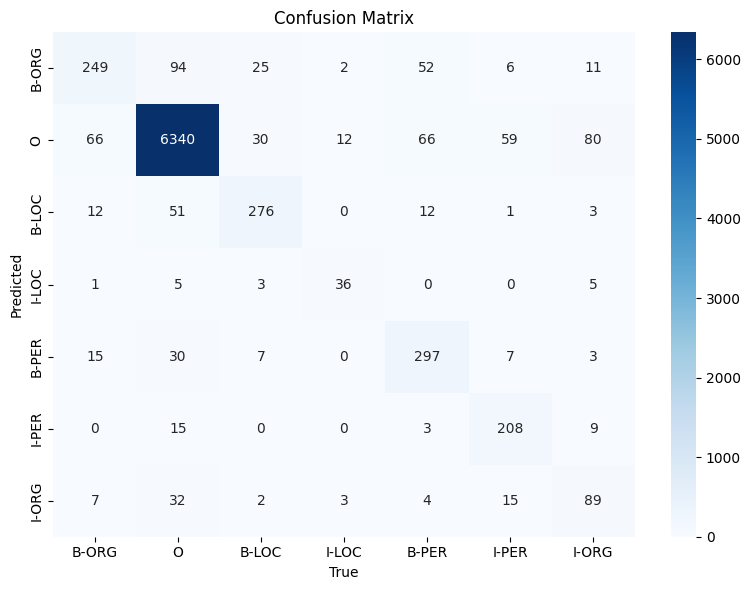

Found pretrained vectors for 3737/7163 words.


Epochs: 100%|██████████| 10/10 [00:36<00:00,  3.62s/it]


+------------+----------+-------------+--------+
| Scope      |   Recall |   Precision |     F1 |
|------------+----------+-------------+--------|
| All labels |   0.8461 |      0.8892 | 0.8576 |
| Without O  |   0.6826 |      0.5696 | 0.5842 |
+------------+----------+-------------+--------+


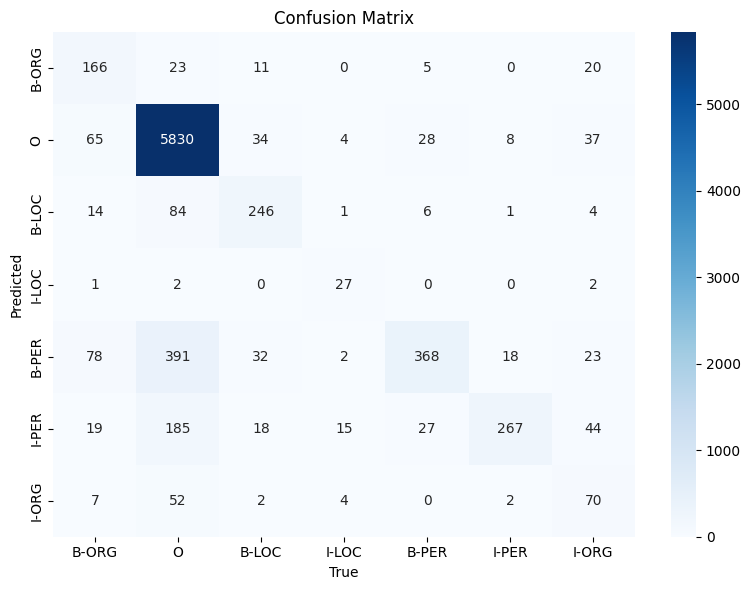

In [81]:
########################################
# Tests

import json

def test_link():
    return {
        'link': NOTEBOOK_LINK
    }

train_ds = read_data("data/train.txt")
dev_ds = read_data("data/dev.txt")
test_ds = read_data("data/test.txt")
def test_read_data():
    result = {
        'lengths': (len(train_ds), len(dev_ds), len(test_ds)),
    }
    return result

vocab = Vocab(train_ds)
def test_vocab():
    sent = vocab.index_words(["I", "am", "Spongebob"])
    return {
        'length': vocab.n_words,
        'tag2id_length': len(vocab.tag2id),
        "Spongebob": sent[2]
    }

train_sequences = prepare_data(train_ds, vocab)
dev_sequences = prepare_data(dev_ds, vocab)
test_sequences = prepare_data(test_ds, vocab)

def test_count_oov():
    return {
        'dev_oov': count_oov(dev_sequences),
        'test_oov': count_oov(test_sequences)
    }

BATCH_SIZE = 16
dl_train = prepare_data_loader(train_sequences, batch_size=BATCH_SIZE)
dl_dev = prepare_data_loader(dev_sequences, batch_size=BATCH_SIZE, train=False)
dl_test = prepare_data_loader(test_sequences, batch_size=BATCH_SIZE, train=False)

def test_prepare_data_loader():
    return {
        'lengths': (len(dl_train), len(dl_dev), len(dl_test))
    }


def test_NERNet():
    # Extract best model configuration
    hidden_size = best_model_cfg['hidden_size']
    n_layers = best_model_cfg['n_layers']
    directions = best_model_cfg['directions']


    # Create model
    best_model = NERNet(vocab.n_words, embedding_size=300, hidden_size=hidden_size, output_size=vocab.n_tags, n_layers=n_layers, directions=directions)
    best_model.to(DEVICE)

    # Train model and evaluate
    _ = train_loop(best_model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
    results = evaluate(best_model, title="", dataloader=dl_test, vocab=vocab)

    return {
        'f1': results['F1'],
        'f1_wo_o': results['F1_WO_O'],
    }

def test_glove():
    # Get embeddings
    emb_file = 'glove.6B.300d.txt'
    emb_matrix = get_emb_matrix(emb_file, vocab)

    # Extract best model configuration
    hidden_size = best_model_glove_cfg['hidden_size']
    n_layers = best_model_glove_cfg['n_layers']
    directions = best_model_glove_cfg['directions']

    # Create model
    best_model = NERNet(vocab.n_words, embedding_size=300, hidden_size=hidden_size, output_size=vocab.n_tags, n_layers=n_layers, directions=directions)
    best_model.to(DEVICE)
    initialize_from_pretrained_emb(best_model, emb_matrix)

    # Train model and evaluate
    _ = train_loop(best_model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
    results = evaluate(best_model, title="", dataloader=dl_test, vocab=vocab)

    return {
        'f1': results['F1'],
        'f1_wo_o': results['F1_WO_O'],
    }

TESTS = [
    test_link,
    test_read_data,
    test_vocab,
    test_count_oov,
    test_prepare_data_loader,
    test_NERNet,
    test_glove
]

# Run tests and save results
res = {}
for test in TESTS:
    try:
        cur_res = test()
        res.update({test.__name__: cur_res})
    except Exception as e:
        import traceback
        res.update({test.__name__: repr(e) + "\n" + traceback.format_exc()})

with open('results.json', 'w') as f:
    json.dump(res, f, indent=2)

########################################

---

# 📤 Submit Your Assignment to GitHub

## Step 1: Authentication Setup (One-Time)

Before you can submit, you need to set up GitHub authentication.

### Creating a GitHub Personal Access Token:

1. **Go to GitHub Token Settings**: [https://github.com/settings/tokens](https://github.com/settings/tokens)

2. **Click "Generate new token (classic)"**

3. **Configure your token**:
   - **Note**: "NLP Course Assignments" (or any name you like)
   - **Expiration**: 90 days (or custom)
   - **Select scopes**: Check **`repo`** (full control of private repositories)

4. **Click "Generate token"**

5. **IMPORTANT**: Copy the token immediately and save it somewhere safe!
   - Like Colab Secrets (see picture)
   - You won't be able to see it again
   - You can reuse this token for all assignments
   - Don't share it with anyone

### Run the authentication cell below

You only need to do this **once per Colab session**. If you restart the runtime, you'll need to re-run the authentication cell.

---

In [82]:
"""
GitHub Authentication Setup
Run this cell ONCE to set up your GitHub credentials
"""

import os
from getpass import getpass

def setup_github_auth():
    """Set up GitHub credentials - run once per Colab session"""
    global GITHUB_USERNAME, GITHUB_TOKEN

    print("🔐 GitHub Authentication Setup")
    print("=" * 60)

    GITHUB_USERNAME = input("GitHub username: ")
    GITHUB_TOKEN = getpass("GitHub Personal Access Token (hidden): ")

    print("\n✅ Credentials saved for this session!")
    print("You can now run the submission cell below.")
    print("\n💡 Tip: Your credentials are only stored in this runtime.")
    print("If you restart the runtime, you'll need to run this cell again.")

# Run the setup
setup_github_auth()

🔐 GitHub Authentication Setup
GitHub username: Yair95
GitHub Personal Access Token (hidden): ··········

✅ Credentials saved for this session!
You can now run the submission cell below.

💡 Tip: Your credentials are only stored in this runtime.
If you restart the runtime, you'll need to run this cell again.


---

## Step 2: Submit Your Results

Once you've:
- ✅ Completed all the code cells above
- ✅ Run all the test cells
- ✅ Generated `results.json`
- ✅ Run the authentication cell

You can now submit your assignment by running the cell below!

### What you'll need:
- Your **GitHub Classroom repository URL**
  - You received this when you accepted the assignment
  - Format: `https://github.com/NLP-Reichman/2026-assignment-2-team-name`
- (Optional) A custom commit message

### After submission:
- Check your repository to see `results.json` has been uploaded
- Visit the **Actions** tab to see your autograding results
- Results typically appear within 1-2 minutes

---

In [ ]:
"""
Submit Assignment to GitHub
Run this cell to push your results.json to GitHub
"""

import os
import subprocess
import json

def check_credentials():
    """Check if credentials are set"""
    try:
        _ = GITHUB_USERNAME
        _ = GITHUB_TOKEN
        return True
    except NameError:
        print("\u274c GitHub credentials not found!")
        print("Please run the authentication cell above first.")
        return False


def check_results_file():
    """Check if results.json exists"""
    if not os.path.exists('results.json'):
        print("\u274c results.json not found!")
        print("\nPlease run all the test cells above to generate results.json")
        return False

    # Display test summary
    try:
        with open('results.json', 'r') as f:
            results = json.load(f)

        print("\U0001f4ca Test Results Found:")
        print("-" * 60)
        for test_name in results.keys():
            print(f"  \u2713 {test_name}")
        print("-" * 60)
        return True
    except Exception as e:
        print(f"\u26a0\ufe0f  Warning: Could not read results.json: {e}")
        return True  # Still allow submission


def submit_to_github(repo_url, commit_message=None):
    """Submit results.json to GitHub repository"""

    if commit_message is None:
        commit_message = "Submit assignment results from Colab"

    print("\n\U0001f680 Submitting to GitHub...")
    print("=" * 60)

    # Create temporary directory
    temp_dir = '/content/github_submission'
    if os.path.exists(temp_dir):
        subprocess.run(['rm', '-rf', temp_dir], check=True, capture_output=True)

    os.makedirs(temp_dir, exist_ok=True)
    os.chdir(temp_dir)

    try:
        # Configure git
        subprocess.run(['git', 'config', '--global', 'user.email',
                       f'{GITHUB_USERNAME}@users.noreply.github.com'],
                      check=True, capture_output=True)
        subprocess.run(['git', 'config', '--global', 'user.name',
                       GITHUB_USERNAME],
                      check=True, capture_output=True)

        # Clone repository with authentication
        auth_url = repo_url.replace('https://', f'https://{GITHUB_USERNAME}:{GITHUB_TOKEN}@')

        print("\U0001f4e5 Cloning repository...")
        result = subprocess.run(['git', 'clone', auth_url, 'repo'],
                              capture_output=True, text=True)

        if result.returncode != 0:
            print(f"\u274c Error cloning repository:")
            print(result.stderr)
            print("\n\U0001f4a1 Troubleshooting:")
            print("  - Check that your repository URL is correct")
            print("  - Verify your token has 'repo' scope")
            print("  - Make sure you've accepted the assignment")
            return False

        # Change to repo directory
        os.chdir('repo')

        # Copy results.json
        print("\U0001f4dd Copying results.json...")
        subprocess.run(['cp', '/content/results.json', 'results.json'],
                      check=True, capture_output=True)

        # Copy CSV result files if they exist
        for csv_file in ['NER_results.csv', 'NER_results_glove.csv']:
            csv_path = f'/content/{csv_file}'
            if os.path.exists(csv_path):
                print(f"\U0001f4dd Copying {csv_file}...")
                subprocess.run(['cp', csv_path, csv_file],
                              check=True, capture_output=True)

        # Check for changes
        status = subprocess.run(['git', 'status', '--porcelain'],
                              capture_output=True, text=True)

        if not status.stdout.strip():
            print("\n\u2139\ufe0f  No changes detected - results.json is unchanged")
            print("\u2705 Your repository is already up to date!")
            return True

        # Commit and push
        print(f"\U0001f4ac Commit message: '{commit_message}'")
        print("\U0001f4e4 Pushing to GitHub...")

        subprocess.run(['git', 'add', 'results.json',
                        'NER_results.csv', 'NER_results_glove.csv'],
                      check=True, capture_output=True)
        subprocess.run(['git', 'commit', '-m', commit_message],
                      check=True, capture_output=True)
        subprocess.run(['git', 'push'],
                      check=True, capture_output=True)

        print("\n" + "=" * 60)
        print("\u2705 SUCCESS! Assignment submitted!")
        print("=" * 60)
        print(f"\n\U0001f4ca Repository: {repo_url}")
        print(f"\U0001f4ca Autograding: {repo_url.replace('.git', '')}/actions")
        print("\n\U0001f4a1 Your grade will appear in the Actions tab in ~1 minute")

        return True

    except subprocess.CalledProcessError as e:
        print(f"\n\u274c Git error occurred")
        if hasattr(e, 'stderr') and e.stderr:
            print(f"Details: {e.stderr}")
        return False
    except Exception as e:
        print(f"\n\u274c Unexpected error: {e}")
        return False
    finally:
        # Return to /content
        os.chdir('/content')


def main():
    """Main submission workflow"""
    print("=" * 60)
    print("\U0001f4e4 Assignment Submission")
    print("=" * 60)

    # Check credentials
    if not check_credentials():
        return

    # Check results file
    if not check_results_file():
        return

    # Get repository URL
    print("\n\U0001f4cd Enter your GitHub Classroom repository URL")
    print("Example: https://github.com/NLP-Reichman/2026-assignment-2-username")
    repo_url = input("\nRepository URL: ").strip()

    # Validate URL
    if not repo_url.startswith('https://github.com/'):
        print("\u274c Invalid URL - must start with https://github.com/")
        return

    # Get commit message (optional)
    print("\n\U0001f4ac Commit Message (optional)")
    print("Press Enter for default message, or type your own:")
    commit_msg = input("Message: ").strip()

    if not commit_msg:
        commit_msg = "Submit assignment results from Colab"

    # Confirm submission
    print("\n" + "=" * 60)
    print("Ready to submit:")
    print(f"  Repository: {repo_url}")
    print(f"  File: results.json")
    print(f"  Message: {commit_msg}")
    print("=" * 60)

    confirm = input("\nProceed? (yes/no): ").strip().lower()

    if confirm in ['yes', 'y']:
        success = submit_to_github(repo_url, commit_msg)
        if success:
            print("\n\U0001f389 All done!")
    else:
        print("\n\u274c Submission cancelled")


# Run submission
main()

📤 Assignment Submission
📊 Test Results Found:
------------------------------------------------------------
  ✓ test_link
  ✓ test_read_data
  ✓ test_vocab
  ✓ test_count_oov
  ✓ test_prepare_data_loader
  ✓ test_NERNet
  ✓ test_glove
------------------------------------------------------------

📍 Enter your GitHub Classroom repository URL
Example: https://github.com/NLP-Reichman/2026-assignment-2-username

Repository URL: https://github.com/NLP-Reichman/assignment-2-ner-yair-and-idan

💬 Commit Message (optional)
Press Enter for default message, or type your own:
